# Chain

## Review

We built a simple graph with nodes, normal edges, and conditional edges.

## Goals

Now, let's build up to a simple chain that combines 4 [concepts](https://python.langchain.com/v0.2/docs/concepts/):

* Using [chat messages](https://python.langchain.com/v0.2/docs/concepts/#messages) as our graph state
* Using [chat models](https://python.langchain.com/v0.2/docs/concepts/#chat-models) in graph nodes
* [Binding tools](https://python.langchain.com/v0.2/docs/concepts/#tools) to our chat model
* [Executing tool calls](https://python.langchain.com/v0.2/docs/concepts/#functiontool-calling) in graph nodes

![Screenshot 2024-08-21 at 9.24.03 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dd607b08df5e1101_chain1.png)

In [1]:
%%capture --no-stderr
%pip install --quiet -U langchain_aws langchain_core langgraph load_dotenv

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["AWS_ACCESS_KEY_ID"] = os.getenv('AWS_ACCESS_KEY_ID')
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv('AWS_SECRET_ACCESS_KEY')
os.environ["AWS_DEFAULT_REGION"] = os.getenv('AWS_DEFAULT_REGION')

## Messages

Chat models can use [`messages`](https://python.langchain.com/v0.2/docs/concepts/#messages), which capture different roles within a conversation.

LangChain supports various message types, including `HumanMessage`, `AIMessage`, `SystemMessage`, and `ToolMessage`.

These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Let's create a list of messages.

Each message can be supplied with a few things:

* `content` - content of the message
* `name` - optionally, a message author
* `response_metadata` - optionally, a dict of metadata (e.g., often populated by model provider for `AIMessages`)

In [3]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
messages = []
messages = [HumanMessage(content=f"Hi, I am Lance. I am researching ocean mammals.", name="Lance")]
messages.append(AIMessage(content=f"So you said you were researching ocean mammals?", name="Model"))
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================ Human Message =================================
Name: Lance

Hi, I am Lance. I am researching ocean mammals.
================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


## Chat Models

[Chat models](https://python.langchain.com/v0.2/docs/concepts/#chat-models) can use a sequence of message as input and support message types, as discussed above.

We can load a chat model and invoke it with out list of messages.

We can see that the result is an `AIMessage` with specific `response_metadata`.

In [4]:
from langchain_aws import ChatBedrock
# --- Chat Model ---
llm = ChatBedrock(
    #model_id="mistral.mistral-7b-instruct-v0:2",
    model_id="amazon.nova-pro-v1:0",
    temperature=1
)
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [5]:
result

AIMessage(content='The best places to see Orcas in the US are:\n\nWashington State.\nCalifornia.\nAlaska.\nHawaii.', additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '842f9071-4539-49b8-a3ae-46521e3bb364', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Tue, 25 Aug 2026 09:01:47 GMT', 'content-type': 'application/json', 'content-length': '297', 'connection': 'keep-alive', 'x-amzn-requestid': '842f9071-4539-49b8-a3ae-46521e3bb364'}, 'RetryAttempts': 0}, 'stopReason': 'end_turn', 'metrics': {'latencyMs': [400]}, 'model_provider': 'bedrock_converse', 'model_name': 'amazon.nova-pro-v1:0'}, id='lc_run--01a03827-78ee-7d20-a7a9-516c2b032299-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 64, 'output_tokens': 22, 'total_tokens': 86, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}})

In [6]:
result.response_metadata

{'ResponseMetadata': {'RequestId': '842f9071-4539-49b8-a3ae-46521e3bb364',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'date': 'Tue, 25 Aug 2026 09:01:47 GMT',
   'content-type': 'application/json',
   'content-length': '297',
   'connection': 'keep-alive',
   'x-amzn-requestid': '842f9071-4539-49b8-a3ae-46521e3bb364'},
  'RetryAttempts': 0},
 'stopReason': 'end_turn',
 'metrics': {'latencyMs': [400]},
 'model_provider': 'bedrock_converse',
 'model_name': 'amazon.nova-pro-v1:0'}

## Tools

Tools are useful whenever you want a model to interact with external systems.

External systems (e.g., APIs) often require a particular input schema or payload, rather than natural language.

When we bind an API, for example, as a tool we given the model awareness of the required input schema.

The model will choose to call a tool based upon the natural language input from the user.

And, it will return an output that adheres to the tool's schema.

[Many LLM providers support tool calling](https://python.langchain.com/v0.1/docs/integrations/chat/) and [tool calling interface](https://blog.langchain.dev/improving-core-tool-interfaces-and-docs-in-langchain/) in LangChain is simple.

You can simply pass any Python `function` into `ChatModel.bind_tools(function)`.

![Screenshot 2024-08-19 at 7.46.28 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dc1c17a7a57f9960_chain2.png)

Let's showcase a simple example of tool calling!

The `multiply` function is our tool.

In [ ]:
# name and description of the tool
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
        
    Returns:
        The product of a and b.
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

If we pass an input - e.g., `"What is 2 multiplied by 3"` - we see a tool call returned.

The tool call has specific arguments that match the input schema of our function along with the name of the function to call.

```
{'arguments': '{"a":2,"b":3}', 'name': 'multiply'}
```

In [8]:
input_message =[]
input_message.append(HumanMessage(content=f"What is 2 multiplied by 3 use tool call", name="Lance"))

tool_call = llm_with_tools.invoke(input_message)

In [9]:
input_message.append(tool_call)
tool_call

AIMessage(content=[{'type': 'reasoning_content', 'reasoning_content': {'text': 'I need to multiply 2 and 3 using the provided tool.'}}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 2, 'b': 3}, 'id': 'tooluse_orgZRmJgvTAq9k4waznhV1'}], additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '548ac74c-bb46-402e-92a0-b552d572da71', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Tue, 25 Aug 2026 09:01:49 GMT', 'content-type': 'application/json', 'content-length': '379', 'connection': 'keep-alive', 'x-amzn-requestid': '548ac74c-bb46-402e-92a0-b552d572da71'}, 'RetryAttempts': 0}, 'stopReason': 'tool_use', 'metrics': {'latencyMs': [536]}, 'model_provider': 'bedrock_converse', 'model_name': 'amazon.nova-pro-v1:0'}, id='lc_run--01a03827-81db-7f43-b1c9-586abc36d546-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'tooluse_orgZRmJgvTAq9k4waznhV1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 424, 'output_tokens': 

In [10]:
# invoke the tool call and pretty print the result
tool_call.pretty_print()


================================== Ai Message ==================================

[{'type': 'reasoning_content', 'reasoning_content': {'text': 'I need to multiply 2 and 3 using the provided tool.'}}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 2, 'b': 3}, 'id': 'tooluse_orgZRmJgvTAq9k4waznhV1'}]
Tool Calls:
  multiply (tooluse_orgZRmJgvTAq9k4waznhV1)
 Call ID: tooluse_orgZRmJgvTAq9k4waznhV1
  Args:
    a: 2
    b: 3


In [11]:
if tool_call.tool_calls:
    for tool_call in tool_call.tool_calls:
        tool_name = tool_call['name']
        tool_args = tool_call['args']
        tool_id = tool_call['id']
        
        # Pull the function from your registry and run it
        if tool_name == "multiply":
            result = multiply(**tool_args)
            print(f"Executed '{tool_name}' with args {tool_args}. Output: {result}")

Executed 'multiply' with args {'a': 2, 'b': 3}. Output: 6


In [12]:
tool_message = ToolMessage(
                content=str(result),
                name=tool_name,
                tool_call_id=tool_id
            )

input_message.append(tool_message)

final_result = llm_with_tools.invoke(input_message)

final_result.pretty_print()

================================== Ai Message ==================================

2 multiplied by 3 is 6.


## Using messages as state

With these foundations in place, we can now use [`messages`](https://python.langchain.com/v0.2/docs/concepts/#messages) in our graph state.

Let's define our state, `MessagesState`, as a `TypedDict` with a single key: `messages`.

`messages` is simply a list of messages, as we defined above (e.g., `HumanMessage`, etc).

In [13]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

## Reducers

Now, we have a minor problem!

As we discussed, each node will return a new value for our state key `messages`.

But, this new value [will override](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers) the prior `messages` value.

As our graph runs, we want to **append** messages to our `messages` state key.

We can use [reducer functions](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers) to address this.

Reducers allow us to specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should *override it* as we saw before.

But, to append messages, we can use the pre-built `add_messages` reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our `messages` key with the `add_messages` reducer function as metadata.

In [14]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

Since having a list of messages in graph state is so common, LangGraph has a pre-built [`MessagesState`](https://langchain-ai.github.io/langgraph/concepts/low_level/#messagesstate)!

`MessagesState` is defined:

* With a pre-build single `messages` key
* This is a list of `AnyMessage` objects
* It uses the `add_messages` reducer

We'll usually use `MessagesState` because it is less verbose than defining a custom `TypedDict`, as shown above.

In [15]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built
    pass

To go a bit deeper, we can see how the `add_messages` reducer works in isolation.

In [16]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='aee5a214-8e86-4a2c-b766-89b4c584fbd8', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='2a2088db-ab3e-43a7-b35d-6b7f9428f69e'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='bca3991d-be74-46a4-9f92-35c4f357c9bc', tool_calls=[], invalid_tool_calls=[])]

## Our graph

Now, lets use `MessagesState` with a graph.

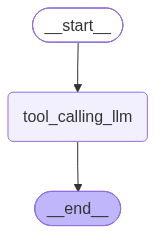

In [17]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

If we pass in `Hello!`, the LLM responds without any tool calls.

In [18]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I assist you today? If you have a mathematical problem involving multiplication, I can help with that.


The LLM chooses to use a tool when it determines that the input or task requires the functionality provided by that tool.

In [19]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================

[{'type': 'reasoning_content', 'reasoning_content': {'text': 'The user wants to multiply 2 and 3. I can use the provided "multiply" tool to perform this operation.'}}, {'type': 'tool_use', 'name': 'multiply', 'input': {'a': 2, 'b': 3}, 'id': 'tooluse_ze1e6Q2eyfR5l8mjTSNq7M'}]
Tool Calls:
  multiply (tooluse_ze1e6Q2eyfR5l8mjTSNq7M)
 Call ID: tooluse_ze1e6Q2eyfR5l8mjTSNq7M
  Args:
    a: 2
    b: 3
